In [1]:
# =========================================
# Setup: libs
# =========================================
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "numpy<2",
    "matplotlib>=3.7,<3.9",
    "torch>=2.0",
    "torchvision>=0.15",
    "scikit-learn>=1.2",
])

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import VGG16_Weights, vgg16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
# =========================================
# Dataset
# =========================================
# Espera uma pasta com subpastas por classe, por exemplo:
# ../data_sets/augmented_1000_ovarian_ultrasound_dataset/Dominant_Follicle
# ../data_sets/augmented_1000_ovarian_ultrasound_dataset/Normal
# ../data_sets/augmented_1000_ovarian_ultrasound_dataset/PCO
DATA_ROOT = Path("../data_sets/augmented_1000_ovarian_ultrasound_dataset")

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_ROOT.resolve()}")

use_predefined_split = (DATA_ROOT / "train").exists() and (DATA_ROOT / "validation").exists()

# ImageNet normalization + light train augmentation.
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

if use_predefined_split:
    train_ds = datasets.ImageFolder(DATA_ROOT / "train", transform=train_tfms)
    val_ds = datasets.ImageFolder(DATA_ROOT / "validation", transform=val_tfms)
    class_names = train_ds.classes
else:
    full_ds_no_tfms = datasets.ImageFolder(DATA_ROOT)
    class_names = full_ds_no_tfms.classes
    targets = [y for _, y in full_ds_no_tfms.samples]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

    train_ds_all = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
    val_ds_all = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)

    train_ds = Subset(train_ds_all, train_idx)
    val_ds = Subset(val_ds_all, val_idx)

print("Dataset:", DATA_ROOT.resolve())
print("Classes:", class_names)

batch_size = 32
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)


Dataset: C:\Users\brian\Desktop\Uni\sistemas_int\ovary\data_sets\augmented_1000_ovarian_ultrasound_dataset
Classes: ['Dominant_Follicle', 'Normal', 'PCO']


In [3]:
# =========================================
# Modelo: VGG16 pre-treinada + cabeca nova
# =========================================
weights = VGG16_Weights.IMAGENET1K_V1
model = vgg16(weights=weights)

# Congela extrator de features para treinamento rapido/estavel.
for p in model.features.parameters():
    p.requires_grad = False

num_classes = len(class_names)
in_feats = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_feats, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# =========================================
# Utilitarios
# =========================================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.set_grad_enabled(train):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
            preds = logits.argmax(1)
            total_loss += loss.item() * y.size(0)
            total_correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc = total_correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, acc, f1, y_true, y_pred


def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch")
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), ha="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\brian/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


[1/3] train_loss=0.8298 acc=0.6825 | val_loss=0.4962 acc=0.8100 f1=0.8148
[2/3] train_loss=0.5436 acc=0.8117 | val_loss=0.4350 acc=0.8233 f1=0.8220
[3/3] train_loss=0.4834 acc=0.8512 | val_loss=0.3863 acc=0.8650 f1=0.8661


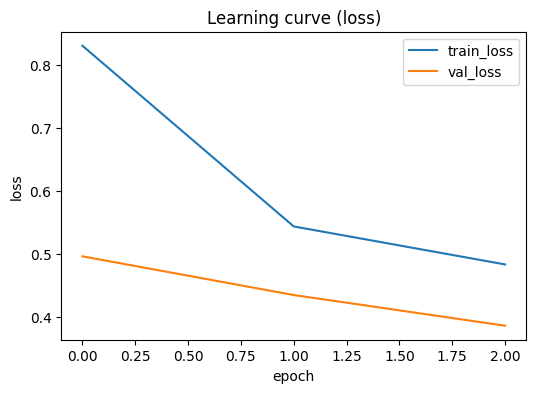

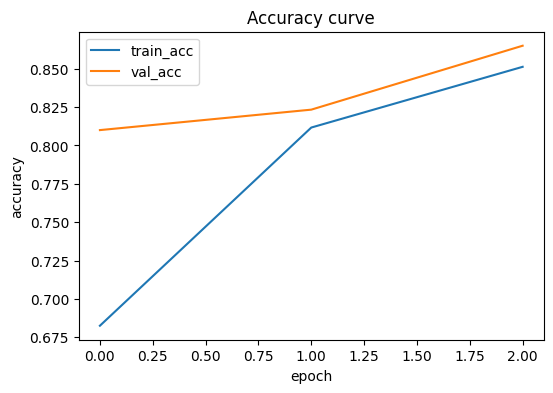


Validation metrics:
Accuracy: 0.8650 | F1 (macro): 0.8661

Classification report:
                    precision    recall  f1-score   support

Dominant_Follicle       0.85      0.79      0.82       200
           Normal       0.99      0.95      0.97       200
              PCO       0.77      0.86      0.81       200

         accuracy                           0.86       600
        macro avg       0.87      0.86      0.87       600
     weighted avg       0.87      0.86      0.87       600



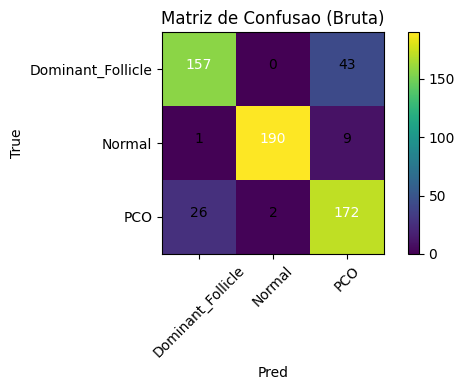

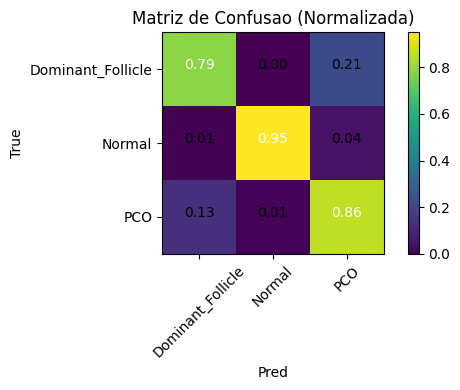

In [4]:
# =========================================
# Treinamento curto
# =========================================
EPOCHS = 3
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

for e in range(1, EPOCHS + 1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["val_f1"].append(va_f1)
    print(f"[{e}/{EPOCHS}] train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

plot_curve(history, "train_loss", "val_loss", "Learning curve (loss)", "loss")
plot_curve(history, "train_acc", "val_acc", "Accuracy curve", "accuracy")

print("\nValidation metrics:")
print(f"Accuracy: {history['val_acc'][-1]:.4f} | F1 (macro): {history['val_f1'][-1]:.4f}")
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=False, title="Matriz de Confusao (Bruta)")
plot_cm(cm, class_names, normalize=True, title="Matriz de Confusao (Normalizada)")
